# Seq2Seq + Attention 한국어→영어 번역기 

##### 이번 Seq2Seq + Attention 한국어→영어 번역기 프로젝트에는 TensorFlow를 사용하여 SentencePiece 기반 한국어 전처리, LSTM 인코더-디코더 구조, Additive Attention 메커니즘, 그리고 Teacher Forcing 학습 방식을 구현

## 1. 라이브러리 준비

TensorFlow, 전처리, 시각화, 체크포인트 저장에 필요한 라이브러리를 불러옵니다.

In [1]:
try:
    import tensorflow as tf
except ImportError:
    %pip install -q tensorflow
    import tensorflow as tf

import os
import re
import tarfile
import warnings
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import sentencepiece as spm
except ImportError:
    %pip install -q sentencepiece
    import sentencepiece as spm

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, AdditiveAttention, Concatenate
from tensorflow.keras.models import Model

print("TensorFlow:", tf.__version__)

# Korean tokenizer: SentencePiece BPE (subword) for better Korean handling than whitespace.
KO_TOKENIZER_MODE = "sentencepiece_bpe"
SPM_MODEL_PREFIX = "korean_spm_bpe"
SPM_VOCAB_SIZE = 8000
sp_processor = None

print("Korean tokenizer mode:", KO_TOKENIZER_MODE)

I0000 00:00:1778053753.595083    8921 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778053753.671918    8921 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778053755.606789    8921 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
Korean tokenizer mode: sentencepiece_bpe


## 2. 데이터 경로와 압축 해제



- `/home/jovyan/work/s2s_translation/data`
- 그 안에 업로드한 `train/dev/test.tar.gz`



In [2]:

BASE_DIR = "/home/jovyan/work/s2s_translation"
DATA_DIR = os.path.join(BASE_DIR, "data")
EXTRACT_DIR = os.path.join(DATA_DIR, "extracted")
MODEL_DIR = os.path.join(BASE_DIR, "models")
CHECKPOINT_DIR = os.path.join(MODEL_DIR, "checkpoints")
LOG_DIR = os.path.join(BASE_DIR, "logs")

for path in [EXTRACT_DIR, MODEL_DIR, CHECKPOINT_DIR, LOG_DIR]:
    os.makedirs(path, exist_ok=True)

file_list = [
    "korean-english-park.train.tar.gz",
    "korean-english-park.dev.tar.gz",
    "korean-english-park.test.tar.gz",
]

for file_name in file_list:
    file_path = os.path.join(DATA_DIR, file_name)
    extract_subdir = os.path.join(EXTRACT_DIR, file_name.replace(".tar.gz", ""))
    if not os.path.exists(file_path):
        print("파일 없음:", file_path)
        continue
    os.makedirs(extract_subdir, exist_ok=True)
    if not os.listdir(extract_subdir):
        with tarfile.open(file_path, "r:gz") as tar:
            tar.extractall(path=extract_subdir, filter="data")
        print("압축 해제:", file_name)
    else:
        print("이미 압축 해제됨:", file_name)

print("CHECKPOINT_DIR =", CHECKPOINT_DIR)
print("LOG_DIR =", LOG_DIR)


이미 압축 해제됨: korean-english-park.train.tar.gz
이미 압축 해제됨: korean-english-park.dev.tar.gz
이미 압축 해제됨: korean-english-park.test.tar.gz
CHECKPOINT_DIR = /home/jovyan/work/s2s_translation/models/checkpoints
LOG_DIR = /home/jovyan/work/s2s_translation/logs


In [3]:
train_ko_path = os.path.join(EXTRACT_DIR, "korean-english-park.train", "korean-english-park.train.ko")
train_en_path = os.path.join(EXTRACT_DIR, "korean-english-park.train", "korean-english-park.train.en")

dev_ko_path = os.path.join(EXTRACT_DIR, "korean-english-park.dev", "korean-english-park.dev.ko")
dev_en_path = os.path.join(EXTRACT_DIR, "korean-english-park.dev", "korean-english-park.dev.en")

test_ko_path = os.path.join(EXTRACT_DIR, "korean-english-park.test", "korean-english-park.test.ko")
test_en_path = os.path.join(EXTRACT_DIR, "korean-english-park.test", "korean-english-park.test.en")

for p in [train_ko_path, train_en_path, dev_ko_path, dev_en_path, test_ko_path, test_en_path]:
    print(os.path.basename(p), "=>", os.path.exists(p))

korean-english-park.train.ko => True
korean-english-park.train.en => True
korean-english-park.dev.ko => True
korean-english-park.dev.en => True
korean-english-park.test.ko => True
korean-english-park.test.en => True


## 3. 데이터 로딩 + 전처리

- 영어: **소문자, 구두점/공백 정리**
- 한국어: **기본 정제 후 SentencePiece BPE 서브워드 적용**
- 너무 길거나 노이즈가 큰 문장은 제거

In [4]:
def load_parallel_corpus(ko_path, en_path):
    with open(ko_path, "r", encoding="utf-8") as f:
        ko_lines = f.read().splitlines()
    with open(en_path, "r", encoding="utf-8") as f:
        en_lines = f.read().splitlines()
    assert len(ko_lines) == len(en_lines), "한국어/영어 줄 수가 다릅니다."
    return list(zip(ko_lines, en_lines))

def preprocess_english(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z?.!,']+", " ", text)
    text = re.sub(r"([?.!,'])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_korean(text):
    text = text.strip()
    text = re.sub(r"[^가-힣0-9a-zA-Z?.!, ]+", " ", text)
    text = re.sub(r"([?.!,])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def train_sentencepiece_tokenizer(texts, model_prefix=SPM_MODEL_PREFIX, vocab_size=SPM_VOCAB_SIZE):
    cleaned_texts = [preprocess_korean(t) for t in texts if preprocess_korean(t)]
    if not cleaned_texts:
        raise ValueError("SentencePiece 학습용 한국어 문장이 없습니다.")

    input_txt = Path(f"{model_prefix}.txt")
    with open(input_txt, "w", encoding="utf-8") as f:
        for line in cleaned_texts:
            f.write(line + "\n")

    model_file = Path(f"{model_prefix}.model")
    vocab_file = Path(f"{model_prefix}.vocab")

    if model_file.exists():
        model_file.unlink()
    if vocab_file.exists():
        vocab_file.unlink()

    spm.SentencePieceTrainer.train(
        input=str(input_txt),
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        model_type="bpe",
        character_coverage=0.9995,
        pad_id=0,
        unk_id=1,
        bos_id=-1,
        eos_id=-1,
        normalization_rule_name="identity",
        split_by_whitespace=False,
        remove_extra_whitespaces=True,
        max_sentence_length=8192,
    )

    sp = spm.SentencePieceProcessor()
    sp.load(str(model_file))
    return sp, str(model_file), str(vocab_file)

def korean_subword_tokenize(text, sp):
    text = preprocess_korean(text)
    return sp.encode(text, out_type=str)

def encode_korean_for_model(text, sp):
    return " ".join(korean_subword_tokenize(text, sp))

def clean_and_filter_pairs(pairs, max_len=20, min_len=2, ratio_limit=2.5):
    cleaned = []
    for ko, en in pairs:
        ko = preprocess_korean(ko)
        en = preprocess_english(en)
        if not ko or not en:
            continue

        ko_len = len(ko.split())
        en_len = len(en.split())

        if ko_len < min_len or en_len < min_len:
            continue
        if ko_len > max_len or en_len > max_len:
            continue
        ratio = max(ko_len / max(en_len, 1), en_len / max(ko_len, 1))
        if ratio > ratio_limit:
            continue

        cleaned.append((ko, en))
    return cleaned

In [5]:
train_pairs_raw = load_parallel_corpus(train_ko_path, train_en_path)
dev_pairs_raw = load_parallel_corpus(dev_ko_path, dev_en_path)
test_pairs_raw = load_parallel_corpus(test_ko_path, test_en_path)

# train은 조금 더 강하게 정제하고, dev/test는 평가용이므로 기준을 약간 완화합니다.
train_pairs = clean_and_filter_pairs(train_pairs_raw, max_len=15, min_len=2, ratio_limit=2.0)
dev_pairs = clean_and_filter_pairs(dev_pairs_raw, max_len=20, min_len=2, ratio_limit=2.5)
test_pairs = clean_and_filter_pairs(test_pairs_raw, max_len=20, min_len=2, ratio_limit=2.5)

print("원본:", len(train_pairs_raw), len(dev_pairs_raw), len(test_pairs_raw))
print("정제:", len(train_pairs), len(dev_pairs), len(test_pairs))

for i in range(min(5, len(train_pairs))):
    print(f"[{i}] KO:", train_pairs[i][0])
    print(f"[{i}] EN:", train_pairs[i][1])
    print("-" * 80)

원본: 94123 1000 2000
정제: 20710 345 648
[0] KO: 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?
[0] EN: much of personal computing is about can you top this ?
--------------------------------------------------------------------------------
[1] KO: 그러나 이것은 또한 책상도 필요로 하지 않는다 .
[1] EN: like all optical mice , but it also doesn ' t need a desk .
--------------------------------------------------------------------------------
[2] KO: 결정적인 순간에 그들의 능력을 증가시켜 줄 그 무엇이 매우 중요합니다 .
[2] EN: something that will boost their capabilities at crucial moments is very important .
--------------------------------------------------------------------------------
[3] KO: 러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다 .
[3] EN: russian special forces used a sedative gas before storming the theatre .
--------------------------------------------------------------------------------
[4] KO: 많은 인질들이 화학 가스의 영향으로 고통을 겪으며 병원으로 옮겨졌다 .
[4] EN: many captives were taken to hospital suffering from the effects of the chemical .
----------------

### 데이터 길이와 정제 결과 시각화

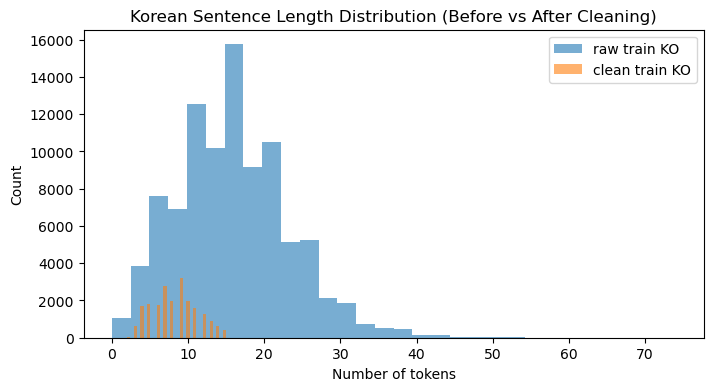

원본 평균 길이: 15.88
정제 후 평균 길이: 8.3
원본 최대 길이: 74
정제 후 최대 길이: 15


In [6]:
# 전처리 전후 문장 길이 분포를 비교해서,
# 필터링이 너무 강하거나 약하지 않은지 확인합니다.
raw_ko_lengths = [len(preprocess_korean(ko).split()) for ko, _ in train_pairs_raw]
clean_ko_lengths = [len(preprocess_korean(ko).split()) for ko, _ in train_pairs]

plt.figure(figsize=(8, 4))
plt.hist(raw_ko_lengths, bins=30, alpha=0.6, label="raw train KO")
plt.hist(clean_ko_lengths, bins=30, alpha=0.6, label="clean train KO")
plt.title("Korean Sentence Length Distribution (Before vs After Cleaning)")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.legend()
plt.show()

print("원본 평균 길이:", round(np.mean(raw_ko_lengths), 2))
print("정제 후 평균 길이:", round(np.mean(clean_ko_lengths), 2))
print("원본 최대 길이:", max(raw_ko_lengths))
print("정제 후 최대 길이:", max(clean_ko_lengths))

### 형태소 분석 / 전처리 확인
한국어 전처리가 실제로 어떻게 적용되는지 예시를 확인합니다.

In [7]:
sample_ko = "러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다."
print("원문 :", sample_ko)
print("기본 정제:", preprocess_korean(sample_ko))
print("토크나이저 방식:", KO_TOKENIZER_MODE)
print("학습 전 서브워드 토크나이징은 아직 수행하지 않습니다.")

원문 : 러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다.
기본 정제: 러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다 .
토크나이저 방식: sentencepiece_bpe
학습 전 서브워드 토크나이징은 아직 수행하지 않습니다.


## 4. 실습용 subset


In [8]:
# CPU 환경을 고려한 기본 실습 크기
TRAIN_SIZE = 10000
DEV_SIZE = 1500
TEST_SIZE = 1500

train_pairs = train_pairs[:TRAIN_SIZE]
dev_pairs = dev_pairs[:DEV_SIZE]
test_pairs = test_pairs[:TEST_SIZE]

print("train:", len(train_pairs))
print("dev:", len(dev_pairs))
print("test:", len(test_pairs))

train_input_texts = [ko for ko, en in train_pairs]
train_target_texts = [f"<start> {en} <end>" for _, en in train_pairs]

dev_input_texts = [ko for ko, en in dev_pairs]
dev_target_texts = [f"<start> {en} <end>" for _, en in dev_pairs]

test_input_texts = [ko for ko, en in test_pairs]
test_target_texts = [f"<start> {en} <end>" for _, en in test_pairs]

# Train SentencePiece only on the source-side training corpus, then encode all source texts.
sp_processor, spm_model_file, spm_vocab_file = train_sentencepiece_tokenizer(
    train_input_texts,
    model_prefix=SPM_MODEL_PREFIX,
    vocab_size=SPM_VOCAB_SIZE,
)

train_input_texts_sp = [encode_korean_for_model(text, sp_processor) for text in train_input_texts]
dev_input_texts_sp = [encode_korean_for_model(text, sp_processor) for text in dev_input_texts]
test_input_texts_sp = [encode_korean_for_model(text, sp_processor) for text in test_input_texts]

print("SentencePiece model:", spm_model_file)
print("SentencePiece vocab:", spm_vocab_file)
print("서브워드 예시 원문:", train_input_texts[0])
print("서브워드 예시 변환:", train_input_texts_sp[0])

train: 10000
dev: 345
test: 648


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: korean_spm_bpe.txt
  input_format: 
  model_prefix: korean_spm_bpe
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 8192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 0
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: -1
  eos_id: -1
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 

SentencePiece model: korean_spm_bpe.model
SentencePiece vocab: korean_spm_bpe.vocab
서브워드 예시 원문: 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?
서브워드 예시 변환: ▁개인 용 ▁컴퓨터 ▁사용 의 ▁상당 ▁부분 은▁이 것 보다 ▁뛰어 날 ▁수▁있 느냐 ▁?


d: freq=5 size=6160 all=129194 active=6765 piece=▁할▁것이다
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=5 size=6180 all=129285 active=6856 piece=▁버락▁오바마
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=5 size=6200 all=129361 active=6932 piece=▁대통령에▁당선
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=5 min_freq=2
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=5 size=6220 all=129448 active=6548 piece=야▁한다고▁말했다
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=4 size=6240 all=129503 active=6603 piece=55
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=4 size=6260 all=129545 active=6645 piece=VS
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=4 size=6280 all=129635 active=6735 piece=▁록
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=4 size=6300 all=129734 active=6834 piece=▁첼
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=4 min_freq=2
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=4 size=6320 all=129837 active=6584 piece=고있
bpe_model_trainer.cc(268

### SentencePiece 적용 전후 토큰화 예시 시각화

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52980 (\N{HANGUL SYLLABLE KEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54504 (\N{HANGUL SYLLABLE PYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt

[원문]
개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?

[SentencePiece 적용 후]
['▁개인', '용', '▁컴퓨터', '▁사용', '의', '▁상당', '▁부분', '은▁이', '것', '보다', '▁뛰어', '날', '▁수▁있', '느냐', '▁?']


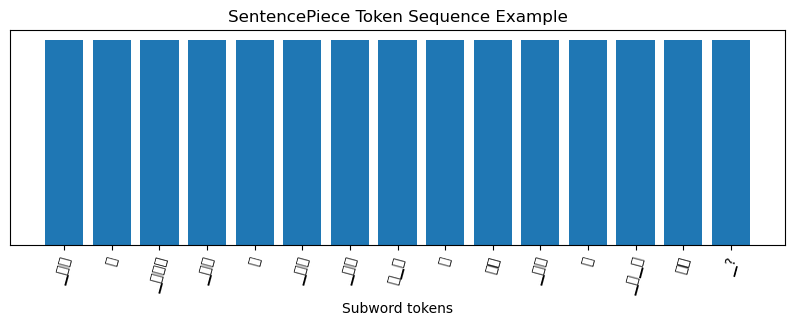

In [9]:
sample_idx = 0
sample_original = train_input_texts[sample_idx]
sample_subword = train_input_texts_sp[sample_idx].split()

print("[원문]")
print(sample_original)
print("\n[SentencePiece 적용 후]")
print(sample_subword)

plt.figure(figsize=(10, 2.8))
plt.bar(range(len(sample_subword)), [1] * len(sample_subword))
plt.xticks(range(len(sample_subword)), sample_subword, rotation=75)
plt.yticks([])
plt.title("SentencePiece Token Sequence Example")
plt.xlabel("Subword tokens")
plt.show()

## TSV 파일 저장

정제된 병렬 말뭉치와 SentencePiece 변환 결과를 TSV 파일로 저장합니다.

In [10]:
import csv
from pathlib import Path

def save_pairs_to_tsv(pairs, path, header=("ko", "en")):
    path = Path(path)
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f, delimiter="\t")
        writer.writerow(header)
        writer.writerows(pairs)
    print(f"저장 완료: {path} ({len(pairs)} rows)")

def save_sentencepiece_tsv(ko_raw_texts, ko_sp_texts, en_raw_texts, path):
    path = Path(path)
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f, delimiter="\t")
        writer.writerow(["ko_raw", "ko_sentencepiece", "en"])
        for ko_raw, ko_sp, en in zip(ko_raw_texts, ko_sp_texts, en_raw_texts):
            writer.writerow([ko_raw, ko_sp, en])
    print(f"저장 완료: {path} ({len(ko_raw_texts)} rows)")

train_en_raw = [en for _, en in train_pairs]
dev_en_raw = [en for _, en in dev_pairs]
test_en_raw = [en for _, en in test_pairs]

save_pairs_to_tsv(train_pairs, "train_pairs.tsv")
save_pairs_to_tsv(dev_pairs, "dev_pairs.tsv")
save_pairs_to_tsv(test_pairs, "test_pairs.tsv")

save_sentencepiece_tsv(train_input_texts, train_input_texts_sp, train_en_raw, "train_sentencepiece.tsv")
save_sentencepiece_tsv(dev_input_texts, dev_input_texts_sp, dev_en_raw, "dev_sentencepiece.tsv")
save_sentencepiece_tsv(test_input_texts, test_input_texts_sp, test_en_raw, "test_sentencepiece.tsv")

저장 완료: train_pairs.tsv (10000 rows)
저장 완료: dev_pairs.tsv (345 rows)
저장 완료: test_pairs.tsv (648 rows)
저장 완료: train_sentencepiece.tsv (10000 rows)
저장 완료: dev_sentencepiece.tsv (345 rows)
저장 완료: test_sentencepiece.tsv (648 rows)


## 5. 토크나이징과 패딩

- `<start>`, `<end>` 토큰을 포함한 target 시퀀스 사용
- decoder input / decoder target을 한 칸씩 밀어서 teacher forcing 적용

In [11]:
SRC_VOCAB_LIMIT = 12000
TGT_VOCAB_LIMIT = 12000

src_tokenizer = Tokenizer(num_words=SRC_VOCAB_LIMIT, filters="")
tgt_tokenizer = Tokenizer(num_words=TGT_VOCAB_LIMIT, filters="")

src_tokenizer.fit_on_texts(train_input_texts_sp)
tgt_tokenizer.fit_on_texts(train_target_texts)

src_vocab_size = min(SRC_VOCAB_LIMIT, len(src_tokenizer.word_index) + 1)
tgt_vocab_size = min(TGT_VOCAB_LIMIT, len(tgt_tokenizer.word_index) + 1)

X_train = src_tokenizer.texts_to_sequences(train_input_texts_sp)
X_dev = src_tokenizer.texts_to_sequences(dev_input_texts_sp)
X_test = src_tokenizer.texts_to_sequences(test_input_texts_sp)

y_train = tgt_tokenizer.texts_to_sequences(train_target_texts)
y_dev = tgt_tokenizer.texts_to_sequences(dev_target_texts)
y_test = tgt_tokenizer.texts_to_sequences(test_target_texts)

max_src_len = max(len(seq) for seq in X_train)
max_tgt_len = max(len(seq) for seq in y_train)

X_train = pad_sequences(X_train, maxlen=max_src_len, padding="post")
X_dev = pad_sequences(X_dev, maxlen=max_src_len, padding="post")
X_test = pad_sequences(X_test, maxlen=max_src_len, padding="post")

y_train = pad_sequences(y_train, maxlen=max_tgt_len, padding="post")
y_dev = pad_sequences(y_dev, maxlen=max_tgt_len, padding="post")
y_test = pad_sequences(y_test, maxlen=max_tgt_len, padding="post")

decoder_input_train = y_train[:, :-1]
decoder_target_train = np.expand_dims(y_train[:, 1:], -1)

decoder_input_dev = y_dev[:, :-1]
decoder_target_dev = np.expand_dims(y_dev[:, 1:], -1)

decoder_input_test = y_test[:, :-1]
decoder_target_test = np.expand_dims(y_test[:, 1:], -1)

print("src vocab size:", src_vocab_size)
print("tgt vocab size:", tgt_vocab_size)
print("max src len:", max_src_len)
print("max tgt len:", max_tgt_len)

src vocab size: 7603
tgt vocab size: 11671
max src len: 47
max tgt len: 17


### 입력/출력 시퀀스 길이 분포 확인

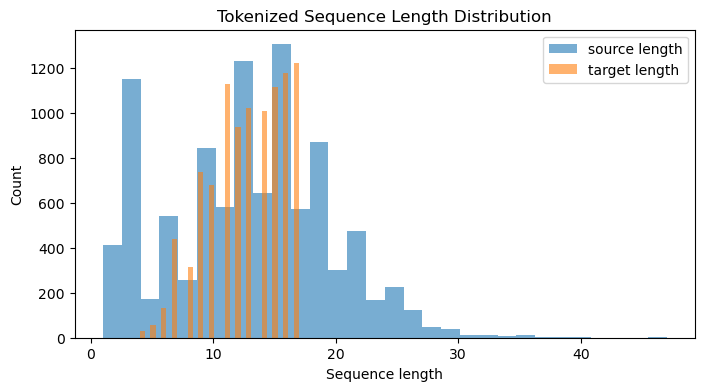

소스 평균 길이: 12.84
타깃 평균 길이: 12.76
소스 95% 지점: 23
타깃 95% 지점: 17


In [12]:
src_seq_lengths = [np.count_nonzero(seq) for seq in X_train]
tgt_seq_lengths = [np.count_nonzero(seq) for seq in y_train]

plt.figure(figsize=(8, 4))
plt.hist(src_seq_lengths, bins=30, alpha=0.6, label="source length")
plt.hist(tgt_seq_lengths, bins=30, alpha=0.6, label="target length")
plt.title("Tokenized Sequence Length Distribution")
plt.xlabel("Sequence length")
plt.ylabel("Count")
plt.legend()
plt.show()

print("소스 평균 길이:", round(np.mean(src_seq_lengths), 2))
print("타깃 평균 길이:", round(np.mean(tgt_seq_lengths), 2))
print("소스 95% 지점:", int(np.percentile(src_seq_lengths, 95)))
print("타깃 95% 지점:", int(np.percentile(tgt_seq_lengths, 95)))

## 6. Attentional Seq2Seq 모델


- Encoder: LSTM
- Decoder: LSTM
- Attention: `AdditiveAttention`
- 출력층: softmax


In [13]:
EMBED_DIM = 96
HIDDEN_SIZE = 128

encoder_inputs = Input(shape=(max_src_len,), name="encoder_inputs")
encoder_embedding_layer = Embedding(src_vocab_size, EMBED_DIM, mask_zero=True, name="encoder_embedding")
encoder_embedding = encoder_embedding_layer(encoder_inputs)

encoder_lstm = LSTM(HIDDEN_SIZE, return_sequences=True, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)

decoder_inputs = Input(shape=(max_tgt_len - 1,), name="decoder_inputs")
decoder_embedding_layer = Embedding(tgt_vocab_size, EMBED_DIM, mask_zero=True, name="decoder_embedding")
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(HIDDEN_SIZE, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=[state_h, state_c])

attention_layer = AdditiveAttention(name="attention_layer")
context_vector = attention_layer([decoder_outputs, encoder_outputs])

concat_layer = Concatenate(axis=-1, name="concat_layer")
decoder_concat = concat_layer([decoder_outputs, context_vector])

decoder_dense = Dense(tgt_vocab_size, activation="softmax", name="decoder_dense")
decoder_outputs = decoder_dense(decoder_concat)

train_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
train_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

train_model.summary()

E0000 00:00:1778053768.092371    8921 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778053768.113426    8921 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 47)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 47, 96)    │    729,888 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 47)        │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 16, 96)    │  1,120,416 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 47, 128), │    115,200 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal[0][0]   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 16, 128), │    115,200 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 16, 128)   │        128 │ decoder_lstm[0][… │
│ (AdditiveAttention) │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_layer        │ (None, 16, 256)   │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 16, 11671) │  2,999,447 │ concat_layer[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,080,279 (19.38 MB)

 Trainable params: 5,080,279 (19.38 MB)

 Non-trainable params: 0 (0.00 B)

## 7. 학습 + 체크포인트 저장

각 에포크마다 가중치를 저장하고, 검증 성능이 가장 좋은 best weight도 따로 저장합니다. 학습 로그는 CSV 파일로 남기고, EarlyStopping으로 과적합을 줄입니다.

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

EPOCHS = 10
BATCH_SIZE = 16

epoch_ckpt_path = os.path.join(CHECKPOINT_DIR, "epoch_{epoch:02d}_valLoss_{val_loss:.4f}.weights.h5")
best_ckpt_path = os.path.join(MODEL_DIR, "best_attention_seq2seq.weights.h5")
csv_log_path = os.path.join(LOG_DIR, "attention_seq2seq_history.csv")

callbacks = [
    ModelCheckpoint(
        filepath=epoch_ckpt_path,
        monitor="val_loss",
        save_weights_only=True,
        save_best_only=False,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=best_ckpt_path,
        monitor="val_loss",
        save_weights_only=True,
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        verbose=1
    ),
    CSVLogger(csv_log_path)
]

history = train_model.fit(
    [X_train, decoder_input_train],
    decoder_target_train,
    validation_data=([X_dev, decoder_input_dev], decoder_target_dev),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/10


W0000 00:00:1778053771.680916    8969 cpu_allocator_impl.cc:82] Allocation of 191217664 exceeds 10% of free system memory.


  1/625 ━━━━━━━━━━━━━━━━━━━━ 37:57 4s/step - accuracy: 0.0000e+00 - loss: 9.3648

W0000 00:00:1778053772.064168    8970 cpu_allocator_impl.cc:82] Allocation of 191217664 exceeds 10% of free system memory.


  2/625 ━━━━━━━━━━━━━━━━━━━━ 3:38 351ms/step - accuracy: 0.0198 - loss: 9.3643  

...

  3/625 ━━━━━━━━━━━━━━━━━━━━ 3:44 361ms/step - accuracy: 0.0371 - loss: 9.3639

W0000 00:00:1778053772.786639    8971 cpu_allocator_impl.cc:82] Allocation of 191217664 exceeds 10% of free system memory.


  4/625 ━━━━━━━━━━━━━━━━━━━━ 3:42 358ms/step - accuracy: 0.0526 - loss: 9.3634

W0000 00:00:1778053773.138258    8972 cpu_allocator_impl.cc:82] Allocation of 191217664 exceeds 10% of free system memory.


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.1768 - loss: 6.4703
Epoch 1: saving model to /home/jovyan/work/s2s_translation/models/checkpoints/epoch_01_valLoss_5.6995.weights.h5

Epoch 1: finished saving model to /home/jovyan/work/s2s_translation/models/checkpoints/epoch_01_valLoss_5.6995.weights.h5

Epoch 1: val_loss improved from None to 5.69951, saving model to /home/jovyan/work/s2s_translation/models/best_attention_seq2seq.weights.h5

Epoch 1: finished saving model to /home/jovyan/work/s2s_translation/models/best_attention_seq2seq.weights.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 239s 377ms/step - accuracy: 0.2283 - loss: 5.7730 - val_accuracy: 0.2254 - val_loss: 5.6995 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.3255 - loss: 4.8882
Epoch 2: saving model to /home/jovyan/work/s2s_translation/models/checkpoints/epoch_02_valLoss_5.4582.weights.h5

Epoch 2: finished saving model to /home/jovyan/work/s2s_translation/models/checkpoints/ep

### 저장된 체크포인트 확인

학습이 끝난 뒤 저장된 체크포인트와 로그 파일을 확인합니다.

In [15]:

print("=== checkpoints ===")
for name in sorted(os.listdir(CHECKPOINT_DIR))[:20]:
    print(name)

print("\n=== logs ===")
for name in sorted(os.listdir(LOG_DIR)):
    print(name)


=== checkpoints ===
epoch_01_valLoss_5.3126.weights.h5
epoch_01_valLoss_5.6883.weights.h5
epoch_01_valLoss_5.6995.weights.h5
epoch_01_valLoss_5.7621.weights.h5
epoch_01_valLoss_5.9267.weights.h5
epoch_01_valLoss_6.0024.weights.h5
epoch_01_valLoss_6.2342.weights.h5
epoch_02_valLoss_5.1163.weights.h5
epoch_02_valLoss_5.4582.weights.h5
epoch_02_valLoss_5.4599.weights.h5
epoch_02_valLoss_5.4801.weights.h5
epoch_02_valLoss_5.5044.weights.h5
epoch_02_valLoss_5.5364.weights.h5
epoch_02_valLoss_5.6163.weights.h5
epoch_03_valLoss_5.0361.weights.h5
epoch_03_valLoss_5.3211.weights.h5
epoch_03_valLoss_5.3349.weights.h5
epoch_03_valLoss_5.3601.weights.h5
epoch_03_valLoss_5.4192.weights.h5
epoch_03_valLoss_5.4216.weights.h5

=== logs ===
attention_seq2seq_exaone_history.csv
attention_seq2seq_history.csv


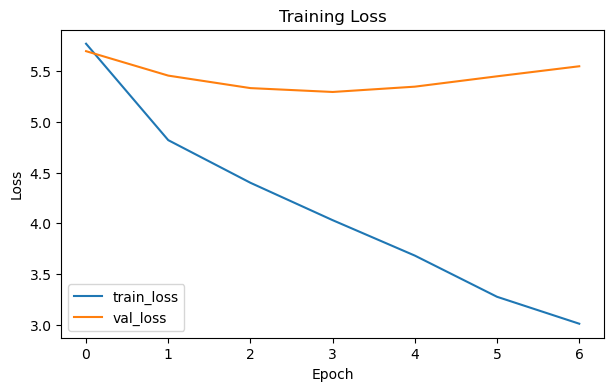

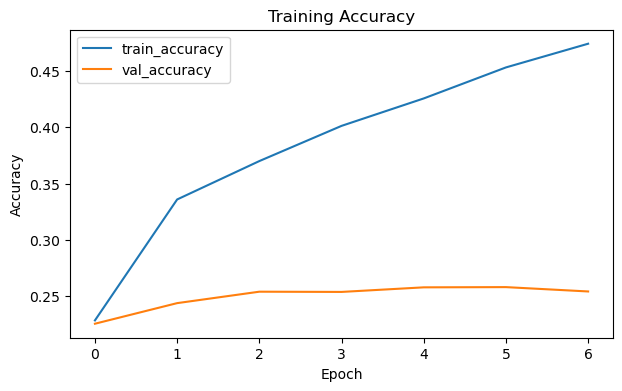

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

if "accuracy" in history.history and "val_accuracy" in history.history:
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["accuracy"], label="train_accuracy")
    plt.plot(history.history["val_accuracy"], label="val_accuracy")
    plt.title("Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

## 8. Best weight 불러오기

Inference 전에 검증 성능이 가장 좋았던 가중치를 다시 불러옵니다.

In [17]:

if os.path.exists(best_ckpt_path):
    train_model.load_weights(best_ckpt_path)
    print("best weight loaded:", best_ckpt_path)
else:
    print("best checkpoint not found. current in-memory weights will be used.")


best weight loaded: /home/jovyan/work/s2s_translation/models/best_attention_seq2seq.weights.h5


## 임베딩 프로젝터용 TSV 내보내기

학습된 임베딩 레이어의 가중치를 `vecs.tsv` / `meta.tsv` 형식으로 저장합니다.  
기본값은 **인코더 임베딩**이며, 필요하면 디코더 임베딩도 함께 저장합니다.


In [18]:

from pathlib import Path

def export_embedding_projector_files(embedding_layer, tokenizer, vecs_path, meta_path, vocab_size=None, skip_pad=True):
    weights = embedding_layer.get_weights()[0]  # (vocab_size, embedding_dim)

    if vocab_size is None:
        vocab_size = weights.shape[0]
    vocab_size = min(vocab_size, weights.shape[0])

    start_idx = 1 if skip_pad else 0
    exported = 0

    vecs_path = Path(vecs_path)
    meta_path = Path(meta_path)

    with vecs_path.open("w", encoding="utf-8") as fv, meta_path.open("w", encoding="utf-8") as fm:
        for i in range(start_idx, vocab_size):
            token = tokenizer.index_word.get(i)
            if token is None:
                continue

            vector = weights[i]
            fv.write("\t".join(map(str, vector.tolist())) + "\n")
            fm.write(str(token).replace("\n", " ") + "\n")
            exported += 1

    print(f"저장 완료: {vecs_path} / {meta_path} ({exported} tokens)")

PROJECTOR_DIR = Path("artifacts/projector")
PROJECTOR_DIR.mkdir(parents=True, exist_ok=True)

# 1) 인코더 임베딩 (한국어 SentencePiece 입력 기준)
export_embedding_projector_files(
    embedding_layer=encoder_embedding_layer,
    tokenizer=src_tokenizer,
    vecs_path=PROJECTOR_DIR / "encoder_vecs.tsv",
    meta_path=PROJECTOR_DIR / "encoder_meta.tsv",
    vocab_size=src_vocab_size,
    skip_pad=True,
)

# TensorBoard Embedding Projector에서 흔히 기대하는 기본 파일명도 함께 저장
export_embedding_projector_files(
    embedding_layer=encoder_embedding_layer,
    tokenizer=src_tokenizer,
    vecs_path=PROJECTOR_DIR / "vecs.tsv",
    meta_path=PROJECTOR_DIR / "meta.tsv",
    vocab_size=src_vocab_size,
    skip_pad=True,
)

# 2) 디코더 임베딩 (영어 출력 토큰 기준) - 필요할 때 함께 비교 가능
export_embedding_projector_files(
    embedding_layer=decoder_embedding_layer,
    tokenizer=tgt_tokenizer,
    vecs_path=PROJECTOR_DIR / "decoder_vecs.tsv",
    meta_path=PROJECTOR_DIR / "decoder_meta.tsv",
    vocab_size=tgt_vocab_size,
    skip_pad=True,
)

print("프로젝터용 파일 위치:", PROJECTOR_DIR.resolve())


저장 완료: artifacts/projector/encoder_vecs.tsv / artifacts/projector/encoder_meta.tsv (7602 tokens)
저장 완료: artifacts/projector/vecs.tsv / artifacts/projector/meta.tsv (7602 tokens)
저장 완료: artifacts/projector/decoder_vecs.tsv / artifacts/projector/decoder_meta.tsv (11670 tokens)
프로젝터용 파일 위치: /home/jovyan/work/s2s_translation/artifacts/projector


## 9. 테스트용 Encoder / Decoder Inference 모델


- **테스트용 디코더 모델이 정상적으로 만들어졌는가**
- 정답과 어느 정도 유사한 영어 번역이 생성되는가

아래 셀에서 inference용 모델을 분리합니다.

In [19]:
encoder_model = Model(
    encoder_inputs,
    [encoder_outputs, state_h, state_c]
)

inf_decoder_inputs = Input(shape=(1,), name="inf_decoder_inputs")
inf_encoder_outputs = Input(shape=(max_src_len, HIDDEN_SIZE), name="inf_encoder_outputs")
inf_state_h = Input(shape=(HIDDEN_SIZE,), name="inf_state_h")
inf_state_c = Input(shape=(HIDDEN_SIZE,), name="inf_state_c")

inf_dec_emb = decoder_embedding_layer(inf_decoder_inputs)
inf_decoder_outputs, inf_out_h, inf_out_c = decoder_lstm(
    inf_dec_emb, initial_state=[inf_state_h, inf_state_c]
)

inf_context = attention_layer([inf_decoder_outputs, inf_encoder_outputs])
inf_concat = concat_layer([inf_decoder_outputs, inf_context])
inf_token_probs = decoder_dense(inf_concat)

decoder_model = Model(
    [inf_decoder_inputs, inf_encoder_outputs, inf_state_h, inf_state_c],
    [inf_token_probs, inf_out_h, inf_out_c]
)

In [20]:
src_index_to_word = {v: k for k, v in src_tokenizer.word_index.items()}
tgt_index_to_word = {v: k for k, v in tgt_tokenizer.word_index.items()}

start_token_id = tgt_tokenizer.word_index["<start>"]
end_token_id = tgt_tokenizer.word_index["<end>"]

def decode_sentence(korean_sentence):
    korean_sentence_sp = encode_korean_for_model(korean_sentence, sp_processor)
    seq = src_tokenizer.texts_to_sequences([korean_sentence_sp])
    seq = pad_sequences(seq, maxlen=max_src_len, padding="post")

    enc_out, h, c = encoder_model.predict(seq, verbose=0)
    target_seq = np.array([[start_token_id]])

    result = []
    for _ in range(max_tgt_len):
        token_probs, h, c = decoder_model.predict([target_seq, enc_out, h, c], verbose=0)
        token_id = int(np.argmax(token_probs[0, -1, :]))

        if token_id == 0 or token_id == end_token_id:
            break

        word = tgt_index_to_word.get(token_id, "")
        if word:
            result.append(word)

        target_seq = np.array([[token_id]])

    sentence = " ".join(result)
    sentence = re.sub(r"\s+([?.!,'])", r"\1", sentence)
    return sentence

## 10. 샘플 번역 확인


이 셀에서 의미가 통하는 수준의 번역문이 나오는지 확인

In [21]:
test_pairs_small = test_pairs[:1000]
print(len(test_pairs_small))

648


In [22]:
if 'test_pairs' in globals() and len(test_pairs) >= 2:
    sample_sentences = [
        test_pairs[0][0],
        test_pairs[1][0],
        "러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다.",
        "많은 인질들이 병원으로 옮겨졌다."
    ]
else:
    sample_sentences = [
        "러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다.",
        "많은 인질들이 병원으로 옮겨졌다."
    ]

for s in sample_sentences:
    print("KO :", s)
    print("EN*:", decode_sentence(s))
    print("-" * 80)

KO : 토론에 참여한 사람들은 법 집행과 국가 안전보장에 대한 우려를 표명해야 할 필요성을 진지하게 받아 들이고 있습니다 .
EN*: the company' s first states is a first time for the world.
--------------------------------------------------------------------------------
KO : 페도로바는 자신의 오랜 남자 친구와 결혼했을지도 모르며
EN*: the first states of the first states for the first states
--------------------------------------------------------------------------------
KO : 러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다.
EN*: the united states was a first time of the first states.
--------------------------------------------------------------------------------
KO : 많은 인질들이 병원으로 옮겨졌다.
EN*: the wounded was killed.
--------------------------------------------------------------------------------


## 11. 정답과 비교해 보기


테스트셋 일부를 정답과 함께 나란히 확인합니다.

In [23]:
import pandas as pd

rows = []
n_show = min(10, len(test_pairs_small))

for i in range(n_show):
    ko_gold, en_gold = test_pairs_small[i]
    en_pred = decode_sentence(ko_gold)
    rows.append({
        "KO": ko_gold,
        "GOLD": en_gold,
        "PRED": en_pred
    })

result_df = pd.DataFrame(rows)
result_df

,KO,GOLD,PRED
0,토론에 참여한 사람들은 법 집행과 국가 안전보장에 대한 우려를 표명해야 할 필요성을...,those involved in the discussions do take seri...,the company' s first states is a first time fo...
1,페도로바는 자신의 오랜 남자 친구와 결혼했을지도 모르며,fedorova might be married to her longtime boyf...,the first states of the first states for the f...
2,"다우 존스 산업 평균 지수가 7 , 683 . 13으로 189 . 02 포인트 하락...","the dow jones industrial average fell . to , ....",the united states was the first first first fi...
3,"나스닥 종합 지수는 1 , 182 . 17로 0 . 23 포인트 하락하여 6년내 최...","the nasdaq composite fell . percent to , . , h...","the first government was killed the first, and..."
4,도쿄의 니케이 지수는 9291 . 03으로 0 . 33 퍼센트 하락했다 .,tokyo ' s nikkei is off . percent to . .,the united states was the first states for the...
5,이 기구는 국가들이 그러한 공격의 가능성에 대비할 것을 촉구했다 .,the agency urged nations to prepare for the po...,the government was been a first time of the fi...
6,"비록 그 위협 의 가능성 은 적지만 , 그 잠재적인 영향력은 가히 파괴적인 것이다 .","even though the threat is small , the potentia...",the company is a first time of the new time of...
7,WHO는 또한 모든 국가들이 생화학 무기를 금지하는 유엔의 조약에 서명하고 이행할 ...,it also called for all countries to sign and e...,the government is also also also have to a fir...
8,"냉전 기간 중에 , 미국과 이전의 소연방은 방대한 양의 세균전 무기를 만들었다 .","during the cold war , the united states and th...",the company' s a first states of the world of ...
9,7월에 부시 행정부는 생물학 무기 금지 조약을 시행하기 위한 협상에서 손을 떼었다 .,"in july , the bush administration pulled out o...",the united states was a first states in the wo...


### 정답 문장과 예측 문장 길이 비교

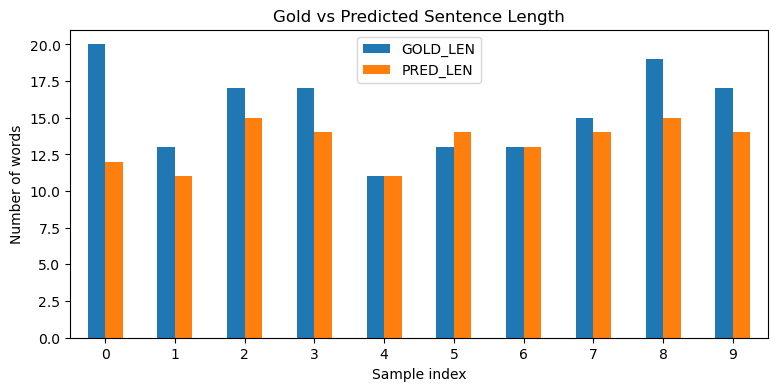

,KO,GOLD,PRED,GOLD_LEN,PRED_LEN
0,토론에 참여한 사람들은 법 집행과 국가 안전보장에 대한 우려를 표명해야 할 필요성을...,those involved in the discussions do take seri...,the company' s first states is a first time fo...,20,12
1,페도로바는 자신의 오랜 남자 친구와 결혼했을지도 모르며,fedorova might be married to her longtime boyf...,the first states of the first states for the f...,13,11
2,"다우 존스 산업 평균 지수가 7 , 683 . 13으로 189 . 02 포인트 하락...","the dow jones industrial average fell . to , ....",the united states was the first first first fi...,17,15
3,"나스닥 종합 지수는 1 , 182 . 17로 0 . 23 포인트 하락하여 6년내 최...","the nasdaq composite fell . percent to , . , h...","the first government was killed the first, and...",17,14
4,도쿄의 니케이 지수는 9291 . 03으로 0 . 33 퍼센트 하락했다 .,tokyo ' s nikkei is off . percent to . .,the united states was the first states for the...,11,11
5,이 기구는 국가들이 그러한 공격의 가능성에 대비할 것을 촉구했다 .,the agency urged nations to prepare for the po...,the government was been a first time of the fi...,13,14
6,"비록 그 위협 의 가능성 은 적지만 , 그 잠재적인 영향력은 가히 파괴적인 것이다 .","even though the threat is small , the potentia...",the company is a first time of the new time of...,13,13
7,WHO는 또한 모든 국가들이 생화학 무기를 금지하는 유엔의 조약에 서명하고 이행할 ...,it also called for all countries to sign and e...,the government is also also also have to a fir...,15,14
8,"냉전 기간 중에 , 미국과 이전의 소연방은 방대한 양의 세균전 무기를 만들었다 .","during the cold war , the united states and th...",the company' s a first states of the world of ...,19,15
9,7월에 부시 행정부는 생물학 무기 금지 조약을 시행하기 위한 협상에서 손을 떼었다 .,"in july , the bush administration pulled out o...",the united states was a first states in the wo...,17,14


In [24]:
result_df["GOLD_LEN"] = result_df["GOLD"].apply(lambda x: len(str(x).split()))
result_df["PRED_LEN"] = result_df["PRED"].apply(lambda x: len(str(x).split()))

plot_df = result_df[["GOLD_LEN", "PRED_LEN"]].head(10)
plot_df.plot(kind="bar", figsize=(9, 4))
plt.title("Gold vs Predicted Sentence Length")
plt.xlabel("Sample index")
plt.ylabel("Number of words")
plt.xticks(rotation=0)
plt.show()

result_df

### 샘플 결과 상세 출력

In [25]:
for i, row in result_df.iterrows():
    print(f"[{i}] KO   : {row['KO']}")
    print(f"[{i}] GOLD : {row['GOLD']}")
    print(f"[{i}] PRED : {row['PRED']}")
    print("=" * 100)

[0] KO   : 토론에 참여한 사람들은 법 집행과 국가 안전보장에 대한 우려를 표명해야 할 필요성을 진지하게 받아 들이고 있습니다 .
[0] GOLD : those involved in the discussions do take seriously the need to address concerns of law enforcement and national security .
[0] PRED : the company' s first states is a first time for the world.
[1] KO   : 페도로바는 자신의 오랜 남자 친구와 결혼했을지도 모르며
[1] GOLD : fedorova might be married to her longtime boyfriend and could be pregnant .
[1] PRED : the first states of the first states for the first states
[2] KO   : 다우 존스 산업 평균 지수가 7 , 683 . 13으로 189 . 02 포인트 하락하여 4년내 최저를 기록했다 .
[2] GOLD : the dow jones industrial average fell . to , . , hitting a four year low .
[2] PRED : the united states was the first first first first, the united states, the united states
[3] KO   : 나스닥 종합 지수는 1 , 182 . 17로 0 . 23 포인트 하락하여 6년내 최저 수준을 새로 기록했다 .
[3] GOLD : the nasdaq composite fell . percent to , . , hitting a new six year low .
[3] PRED : the first government was killed the first, and the first states, the united states.
[4] KO 

# Appendix. EXAONE 토크나이저 비교 실험

본 프로젝트의 메인 결과는 기존 Attention Seq2Seq 번역기 결과를 기준으로 정리하였다.  
아래 내용은 추가 실험으로, 동일한 번역 문제에 대해 **EXAONE 토크나이저를 적용했을 때 어떤 차이가 나타나는지** 확인하기 위한 비교 섹션이다.

이 실험의 목적은 EXAONE 모델 자체를 학습하는 것이 아니라,  
**토크나이저만 변경했을 때 토큰 분절 방식, 시퀀스 길이, 번역 결과가 어떻게 달라지는지**를 확인하는 것이다.

## 1. EXAONE 토크나이저 준비

이 섹션은 Hugging Face의 EXAONE 토크나이저를 사용한다.  

In [26]:
!pip install -q transformers sentencepiece

In [27]:
from transformers import AutoTokenizer

EXAONE_MODEL_NAME = "LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct"
exaone_tokenizer = AutoTokenizer.from_pretrained(EXAONE_MODEL_NAME, trust_remote_code=True)

print("Loaded tokenizer:", EXAONE_MODEL_NAME)
print("pad_token:", exaone_tokenizer.pad_token)
print("bos_token:", exaone_tokenizer.bos_token)
print("eos_token:", exaone_tokenizer.eos_token)
print("unk_token:", exaone_tokenizer.unk_token)
print("vocab size:", len(exaone_tokenizer))

Loaded tokenizer: LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct
pad_token: [PAD]
bos_token: [BOS]
eos_token: [|endofturn|]
unk_token: [UNK]
vocab size: 102400


## 2. 토큰화 방식 비교

아래 셀은 같은 한국어 문장을  
- 공백 기준 토큰화  
- EXAONE 토크나이저 토큰화  

로 각각 비교해서 보여준다.

이를 통해 EXAONE 토크나이저가 기존 방식과 다르게 **subword 단위로 더 세밀하게 분절**한다는 점을 확인할 수 있다.

In [28]:
sample_texts = [
    "러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다.",
    "많은 인질들이 병원으로 옮겨졌다.",
    "개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐?"
]

for text in sample_texts:
    print("[원문]")
    print(text)
    print("[공백 기준]")
    print(text.split())
    print("[EXAONE 토큰]")
    print(exaone_tokenizer.tokenize(text))
    print("=" * 100)

[원문]
러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다.
[공백 기준]
['러시아', '특수', '부대는', '극장으로', '공격해', '들어가기', '전에', '신경', '독가스를', '사용했다.']
[EXAONE 토큰]
['ëŁ¬ìĭľìķĦ', 'ĠíĬ¹ìĪĺ', 'Ġë¶ĢëĮĢ', 'ëĬĶ', 'Ġê·¹ìŀ¥', 'ìľ¼ë¡ľ', 'Ġê³µê²©', 'íķ´', 'Ġëĵ¤ìĸ´ê°Ģ', 'ê¸°', 'ĠìłĦ', 'ìĹĲ', 'Ġìĭłê²½', 'Ġëıħ', 'ê°ĢìĬ¤', 'ë¥¼', 'ĠìĤ¬ìļ©', 'íĸĪ', 'ëĭ¤', '.']
[원문]
많은 인질들이 병원으로 옮겨졌다.
[공백 기준]
['많은', '인질들이', '병원으로', '옮겨졌다.']
[EXAONE 토큰]
['ë§İ', 'ìĿĢ', 'ĠìĿ¸ì§Ī', 'ëĵ¤ìĿ´', 'Ġë³ĳìĽĲ', 'ìľ¼ë¡ľ', 'Ġìĺ®ê²¨ì¡Į', 'ëĭ¤', '.']
[원문]
개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐?
[공백 기준]
['개인용', '컴퓨터', '사용의', '상당', '부분은', '이것보다', '뛰어날', '수', '있느냐?']
[EXAONE 토큰]
['ê°ľìĿ¸', 'ìļ©', 'Ġì»´íĵ¨íĦ°', 'ĠìĤ¬ìļ©', 'ìĿĺ', 'Ġìĥģëĭ¹', 'Ġë¶Ģë¶Ħ', 'ìĿĢ', 'ĠìĿ´ê²ĥ', 'ë³´ëĭ¤', 'ĠëĽ°ìĸ´', 'ëĤł', 'ĠìĪĺ', 'ĠìŀĪ', 'ëĬĲ', 'ëĥĲ', '?']


In [29]:
sample_texts = [
    "러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다.",
    "많은 인질들이 병원으로 옮겨졌다.",
    "개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐?"
]

for text in sample_texts:
    ids = exaone_tokenizer.encode(text, add_special_tokens=False)
    decoded = exaone_tokenizer.decode(ids)

    print("[원문]")
    print(text)
    print("[token ids]")
    print(ids[:50])
    print("[decode 복원]")
    print(decoded)
    print("=" * 100)

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[원문]
러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다.
[token ids]
[43798, 12752, 13232, 657, 21115, 13456, 6779, 999, 3086, 722, 987, 2373, 4901, 3097, 15393, 4605, 1821, 2662, 643, 375]
[decode 복원]
러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다.
[원문]
많은 인질들이 병원으로 옮겨졌다.
[token ids]
[5709, 732, 65860, 14178, 4045, 13456, 81362, 643, 375]
[decode 복원]
많은 인질들이 병원으로 옮겨졌다.
[원문]
개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐?
[token ids]
[9998, 1018, 9231, 1821, 730, 5950, 2578, 732, 4383, 30885, 12249, 1945, 868, 773, 3016, 5133, 392]
[decode 복원]
개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐?


## 3. 평균 시퀀스 길이 비교

EXAONE 토크나이저는 보통 단어를 더 잘게 나누기 때문에,  
같은 문장이라도 시퀀스 길이가 더 길어질 수 있다.

이는 한국어 분절을 더 세밀하게 처리할 수 있다는 장점이 있지만,  
LSTM 기반 Seq2Seq에서는 학습을 더 어렵게 만들 수도 있다.

In [30]:
length_sample_texts = train_input_texts[:500] if 'train_input_texts' in globals() else [x[0] for x in train_pairs[:500]]

basic_lengths = [len(preprocess_korean(text).split()) for text in length_sample_texts]
sp_lengths = [len(korean_subword_tokenize(text, sp_processor)) for text in length_sample_texts]
exaone_lengths = [len(exaone_tokenizer.tokenize(text)) for text in length_sample_texts]

print("기본 공백 토큰 평균 길이:", sum(basic_lengths) / len(basic_lengths))
print("SentencePiece 토큰 평균 길이:", sum(sp_lengths) / len(sp_lengths))
print("EXAONE 토큰 평균 길이:", sum(exaone_lengths) / len(exaone_lengths))
print("기본 공백 토큰 최대 길이:", max(basic_lengths))
print("SentencePiece 토큰 최대 길이:", max(sp_lengths))
print("EXAONE 토큰 최대 길이:", max(exaone_lengths))

기본 공백 토큰 평균 길이: 9.134
SentencePiece 토큰 평균 길이: 14.31
EXAONE 토큰 평균 길이: 18.35
기본 공백 토큰 최대 길이: 15
SentencePiece 토큰 최대 길이: 40
EXAONE 토큰 최대 길이: 33


### 토크나이저별 평균 길이 비교 시각화

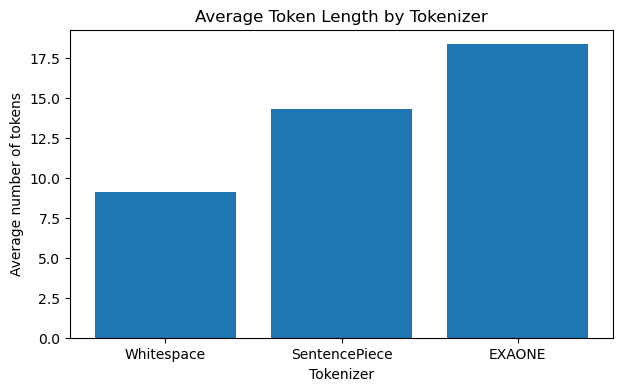

{'Whitespace': np.float64(9.13), 'SentencePiece': np.float64(14.31), 'EXAONE': np.float64(18.35)}


In [31]:
avg_lengths = {
    "Whitespace": np.mean(basic_lengths),
    "SentencePiece": np.mean(sp_lengths),
    "EXAONE": np.mean(exaone_lengths),
}

plt.figure(figsize=(7, 4))
plt.bar(list(avg_lengths.keys()), list(avg_lengths.values()))
plt.title("Average Token Length by Tokenizer")
plt.xlabel("Tokenizer")
plt.ylabel("Average number of tokens")
plt.show()

print({k: round(v, 2) for k, v in avg_lengths.items()})

## 4. Vocabulary 규모 확인

EXAONE 토크나이저는 매우 큰 vocabulary를 가진다.  
이 점은 희귀 단어 처리에는 유리할 수 있지만,  
소형 LSTM Seq2Seq 모델에서는 **출력 공간이 너무 커져 학습 난이도를 높이는 요인**이 될 수 있다.

In [32]:
print("EXAONE tokenizer vocab size:", len(exaone_tokenizer))

if 'src_tokenizer' in globals():
    print("기존 입력 tokenizer vocab size:", len(src_tokenizer.word_index) + 1)

if 'tgt_tokenizer' in globals():
    print("기존 출력 tokenizer vocab size:", len(tgt_tokenizer.word_index) + 1)

EXAONE tokenizer vocab size: 102400
기존 입력 tokenizer vocab size: 7603
기존 출력 tokenizer vocab size: 11671


## 5. EXAONE 결과 비교 해석

EXAONE 토크나이저 버전의 별도 실험에서는 토큰 분절 방식과 시퀀스 길이 변화는 확인할 수 있었지만,  
현재 실험 조건에서는 번역 품질이 반드시 좋아지지는 않았다.

특히 일부 결과에서는 반복 생성(looping)이나 문장 붕괴 현상이 나타났으며,  
이는 다음과 같은 이유로 해석할 수 있다.

- EXAONE 토크나이저와 LSTM Seq2Seq 구조의 궁합 문제
- 매우 큰 vocabulary에 따른 출력 공간 증가
- 제한된 학습 데이터 규모
- greedy decoding의 반복 생성 문제

In [33]:
import pandas as pd

comparison_rows = [
    {
        "KO": "러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다.",
        "기존 토크나이저 결과": "",
        "EXAONE 토크나이저 해석": "subword 분절이 훨씬 세밀해짐"
    },
    {
        "KO": "많은 인질들이 병원으로 옮겨졌다.",
        "기존 토크나이저 결과": "",
        "EXAONE 토크나이저 해석": "짧은 문장에서도 토큰 수가 증가할 수 있음"
    },
    {
        "KO": "개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐?",
        "기존 토크나이저 결과": "",
        "EXAONE 토크나이저 해석": "한국어 복합 어절이 더 잘게 나뉨"
    }
]

pd.DataFrame(comparison_rows)

,KO,기존 토크나이저 결과,EXAONE 토크나이저 해석
0,러시아 특수 부대는 극장으로 공격해 들어가기 전에 신경 독가스를 사용했다.,,subword 분절이 훨씬 세밀해짐
1,많은 인질들이 병원으로 옮겨졌다.,,짧은 문장에서도 토큰 수가 증가할 수 있음
2,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐?,,한국어 복합 어절이 더 잘게 나뉨


## 6. 실험 해석

이번 비교 실험을 통해 EXAONE 토크나이저는 기존 공백 기반 또는 단순 토크나이저 방식과 다른  
**세밀한 subword 분절**을 수행한다는 점을 확인할 수 있었다.

하지만 이번 프로젝트에서는 EXAONE 모델 전체를 사용하는 것이 아니라,  
기존 LSTM 기반 Attention Seq2Seq 구조에 **토크나이저만 교체**하여 적용했기 때문에,  
토큰화의 장점이 곧바로 번역 품질 향상으로 이어지지는 않았다.

즉, 이번 결과는  
**"더 강력한 토크나이저를 쓰면 자동으로 성능이 좋아진다"** 는 것을 보여주기보다는,  
**"토크나이저, 데이터, 모델 구조는 함께 맞물려야 한다"** 는 점을 보여주는 추가 실험이라고 해석할 수 있다.

## 7. 최종 결론

본 프로젝트의 메인 결과는 기존 Attention Seq2Seq 번역기 노트북을 기준으로 제시한다.  
EXAONE 토크나이저 비교 실험은 추가 탐구로 수행하였으며, 다음과 같은 의미가 있다.

- 한국어 토큰 분절 방식의 차이를 확인할 수 있었다.
- EXAONE 토크나이저 적용 시 시퀀스 길이와 vocabulary 규모가 크게 달라짐을 확인했다.
- 하지만 이번 실험 조건에서는 번역 품질이 안정적으로 개선되었다고 보기 어려웠다.

따라서 EXAONE 실험은 **메인 결과를 대체하는 것이 아니라, 추가 비교 실험과 분석 인사이트를 제공하는 부록**으로 제시하는 것이 적절하다.